In [22]:
# website

In [23]:
import os

pwd = os.getcwd()
if pwd.endswith("notebooks"):
    os.chdir("..")

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [25]:
df = pd.read_csv("./dataset/website_engagement_data.csv")
df

,user_id,age_group,layout,time_spent
0,1001,Young,Old_Layout,13.68
1,1002,Older,New_Layout,6.76
2,1003,Older,Old_Layout,4.66
3,1004,Older,New_Layout,8.55
4,1005,Young,New_Layout,19.37
...,...,...,...,...
995,1996,Young,Old_Layout,14.15
996,1997,Older,Old_Layout,6.53
997,1998,Young,Old_Layout,18.13
998,1999,Older,New_Layout,5.62


In [26]:
for layout in df["layout"].unique():
    print(layout, df[df['layout'] == layout]['time_spent'].mean())

Old_Layout 12.501732101616629
New_Layout 9.730546737213404


In [27]:
X_layout = (df["layout"] == "New_Layout").astype(float).values
X = np.column_stack([np.ones(len(df)), X_layout])   
y = df["time_spent"].values

beta, *_ = np.linalg.lstsq(X, y, rcond=None)
intercept, coef_layout = beta

print( coef_layout)


-2.7711853644032156


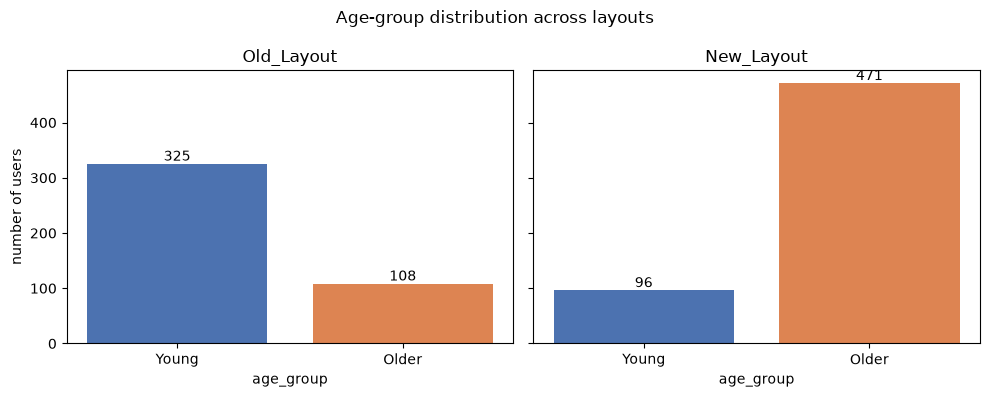

In [28]:
layouts = ["Old_Layout", "New_Layout"]
age_order = ["Young", "Older"]
colors = ["#4C72B0", "#DD8452"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, layout in zip(axes, layouts):
    counts = df[df["layout"] == layout]["age_group"].value_counts().reindex(age_order)
    ax.bar(age_order, counts.values, color=colors)
    ax.set_title(layout)
    ax.set_xlabel("age_group")
    for i, v in enumerate(counts.values):
        ax.text(i, v, str(int(v)), ha="center", va="bottom")

axes[0].set_ylabel("number of users")
fig.suptitle("Age-group distribution across layouts")
plt.savefig("../report/images/web_age.png", dpi=300)
plt.tight_layout()
plt.show()


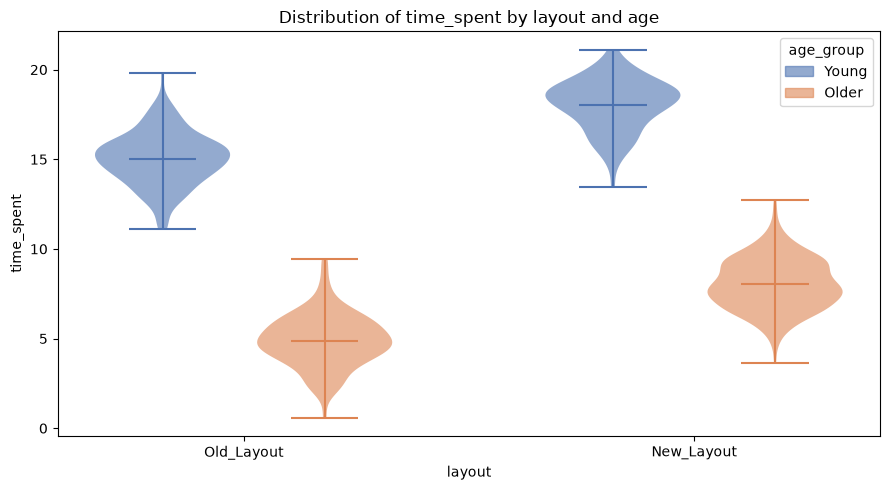

In [29]:
ages = ["Young", "Older"]
offset = {"Young": -0.18, "Older": 0.18}
colors = {"Young": "#4C72B0", "Older": "#DD8452"}

fig, ax = plt.subplots(figsize=(9, 5))
for age in ages:
    data = [df[(df["layout"] == lay) & (df["age_group"] == age)]["time_spent"].values
            for lay in layouts]
    positions = [i + offset[age] for i in range(len(layouts))]
    parts = ax.violinplot(data, positions=positions, widths=0.3,
                          showmeans=True, showmedians=False)
    for body in parts["bodies"]:
        body.set_facecolor(colors[age])
        body.set_alpha(0.6)
    for key in ("cbars", "cmins", "cmaxes", "cmeans"):
        parts[key].set_color(colors[age])

ax.set_xticks(range(len(layouts)))
ax.set_xticklabels(layouts)
ax.set_xlabel("layout")
ax.set_ylabel("time_spent")
ax.set_title("Distribution of time_spent by layout and age")
handles = [plt.Rectangle((0, 0), 1, 1, color=colors[a], alpha=0.6) for a in ages]
ax.legend(handles, ages, title="age_group")
plt.tight_layout()
plt.savefig("../report/images/web_violin.png", dpi=300)
plt.show()
